In [13]:

# --- Jupyter Notebook Cell ---

# 1. Imports
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

# import all functions from all the modules in the code directory
from data_loader import *
from data_eda import *
from data_labels import *
from data_prep import *
from data_quality import *
from data_transform import *
from data_features import *
DATA_DIR = "C:\\Users\\chenj\\Downloads\\thermal-prediction\\thermal-prediction\\data\\raw"

raw_df = load_and_merge_sessions(DATA_DIR)
df_no_gaps = trim_and_handle_gaps(raw_df) #Fill timestamp gap
df_imputed = handle_missing_values(df_no_gaps, missing_threshold=0.1) #Fill NaN
df_final = construct_labels(df_imputed, temp_threshold_c=75.0) #Why predict future label of the current data?
verify_target_distribution(df_final) # What represents thermal_pressure_code



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2026-07-05 22:30:23,630 [INFO] Loaded mac_m1_20260701_001 with 2071 rows.
2026-07-05 22:30:23,644 [INFO] Loaded mac_m1_20260702_001 with 1886 rows.
2026-07-05 22:30:23,658 [INFO] Loaded mac_m1_20260703_001 with 1338 rows.
2026-07-05 22:30:23,668 [INFO] Loaded mac_m5_20260625_001 with 211 rows.
2026-07-05 22:30:23,684 [INFO] Loaded mac_m5_20260626_001 with 2261 rows.
2026-07-05 22:30:23,696 [INFO] Loaded mac_m5_20260626_002 with 864 rows.
2026-07-05 22:30:23,706 [INFO] Loaded mac_m5_20260626_003 with 572 rows.
2026-07-05 22:30:23,718 [INFO] Loaded mac_m5_20260627_001 with 1346 rows.
2026-07-05 22:30:23,724 [INFO] Successfully merged 8 sessions. Total rows: 10549
2026-07-05 22:30:23,734 [INFO] Trimmed the first 5 and last 3 rows from all sessions.
2026-07-05 22:30:23,738 [INFO] Detected 20 temporal gaps exceeding 7 seconds after trimming.
2026-07-05 22:30:23,739 [INFO] Forward-filling missing numeric values for 1 minor gaps.
2026-07-05 22:30:23,747 [INFO] Imputing gaps for 'cpu_die_temp_


--- Target Variable Distributions ---

Target: Y (binary label)
  Class 0: 9432 rows (90.79%)
  Class 1: 957 rows (9.21%)

Target: thermal_pressure_code
  Code 0.0: 9904 rows (95.33%)
  Code 1.0: 402 rows (3.87%)
  Code 2.0: 83 rows (0.80%)


In [14]:
df_final.columns # what are  'loadavg_1m', 'loadavg_5m', 'loadavg_15m'

Index(['timestamp_utc', 'os_family', 'thermal_pressure_level',
       'thermal_pressure_code', 'cpu_die_temp_c', 'cpu_total_active_pct',
       'cpu_ecluster_active_pct', 'cpu_pcluster_active_pct',
       'cpu_ecluster_freq_mhz', 'cpu_pcluster_freq_mhz', 'gpu_active_pct',
       'cpu_power_mw', 'gpu_power_mw', 'combined_power_mw', 'loadavg_1m',
       'loadavg_5m', 'loadavg_15m', 'ram_used_gb', 'mem_pressure_pct',
       'mem_compressed_gb', 'session_id', 'Y'],
      dtype='str')

In [15]:
print_numeric_descriptive_stats(df_final)


--- Descriptive Statistics for Numeric Non-Binary Columns ---


,count,mean,std,min,25%,50%,75%,max,missing_count,missing_pct
thermal_pressure_code,10389.0,0.054673,0.260133,0.000000,0.000000,0.000000,0.000000,2.000000,0,0.0
cpu_die_temp_c,10389.0,51.179601,12.022608,10.640909,41.027344,46.422440,60.638672,80.886292,0,0.0
cpu_total_active_pct,10389.0,48.898584,15.465882,16.571450,38.540950,45.865050,57.388100,99.764385,0,0.0
cpu_ecluster_active_pct,10389.0,60.809472,15.978223,16.438600,51.804700,59.703500,69.433200,100.000000,0,0.0
cpu_pcluster_active_pct,10389.0,36.987697,22.876271,14.932500,21.741500,29.647000,41.592300,100.000000,0,0.0
cpu_ecluster_freq_mhz,10389.0,1558.915935,330.343972,989.901000,1296.730000,1472.260000,1746.550000,2965.220000,0,0.0
cpu_pcluster_freq_mhz,10389.0,2620.957487,1092.748928,1079.150000,1544.130000,2619.750000,3664.740000,4433.820000,0,0.0
gpu_active_pct,10389.0,9.268974,10.419802,0.000000,1.825000,5.200800,13.396500,82.730200,0,0.0
cpu_power_mw,10389.0,3034.640647,5441.154686,418.091000,830.017000,1182.590000,1871.290000,24804.100000,0,0.0
gpu_power_mw,10389.0,58.696395,102.716374,0.000000,5.381740,14.771300,67.962700,1467.080000,0,0.0


2026-07-05 22:30:24,100 [INFO] Generating KDE plots for 17 variables across a 6x3 grid.


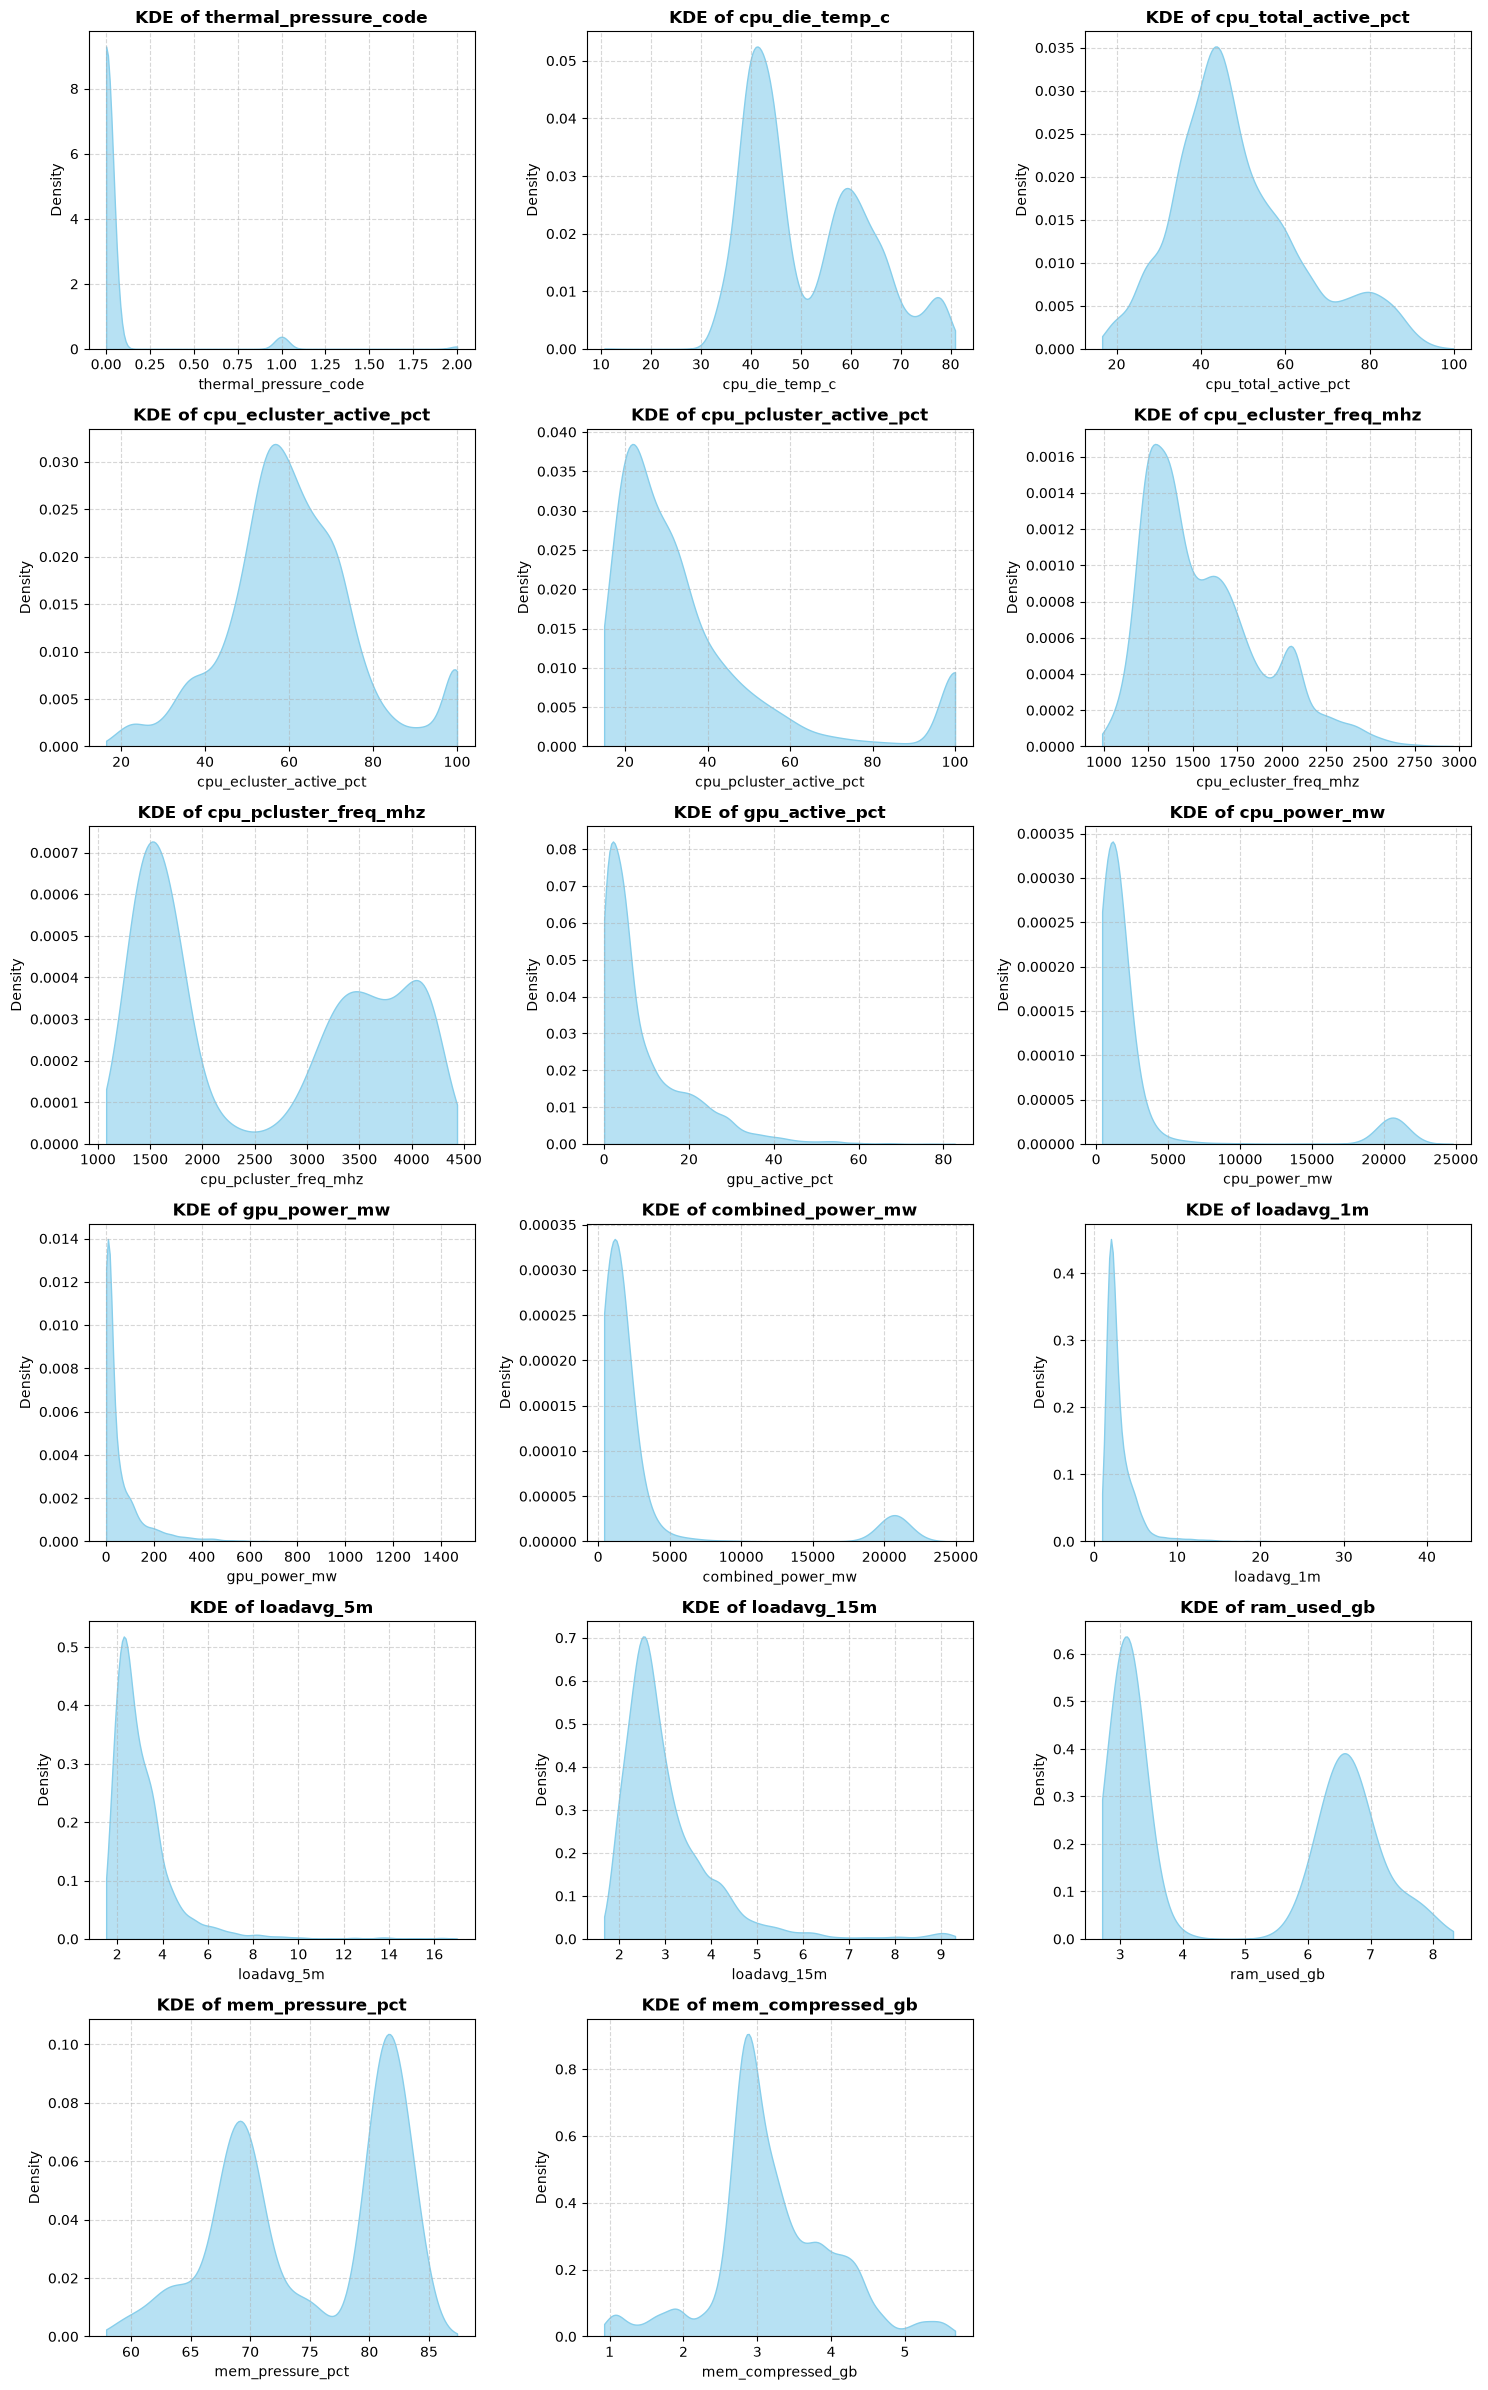

In [16]:
plot_numeric_kdes(df_final)

2026-07-05 22:30:25,690 [WARNING] The following requested columns were missing from the DataFrame and will be skipped: ['cpu_power_mw_is_outlier']
2026-07-05 22:30:25,690 [INFO] Generating pairplot for 8 features...


Notice: No specific columns provided. The pairplot defaults to:
  - mem_compressed_gb
  - cpu_pcluster_freq_mhz
  - cpu_power_mw
  - loadavg_1m
  - cpu_pcluster_active_pct
  - cpu_total_active_pct
  - combined_power_mw
  - cpu_power_mw_is_outlier
  - cpu_ecluster_freq_mhz



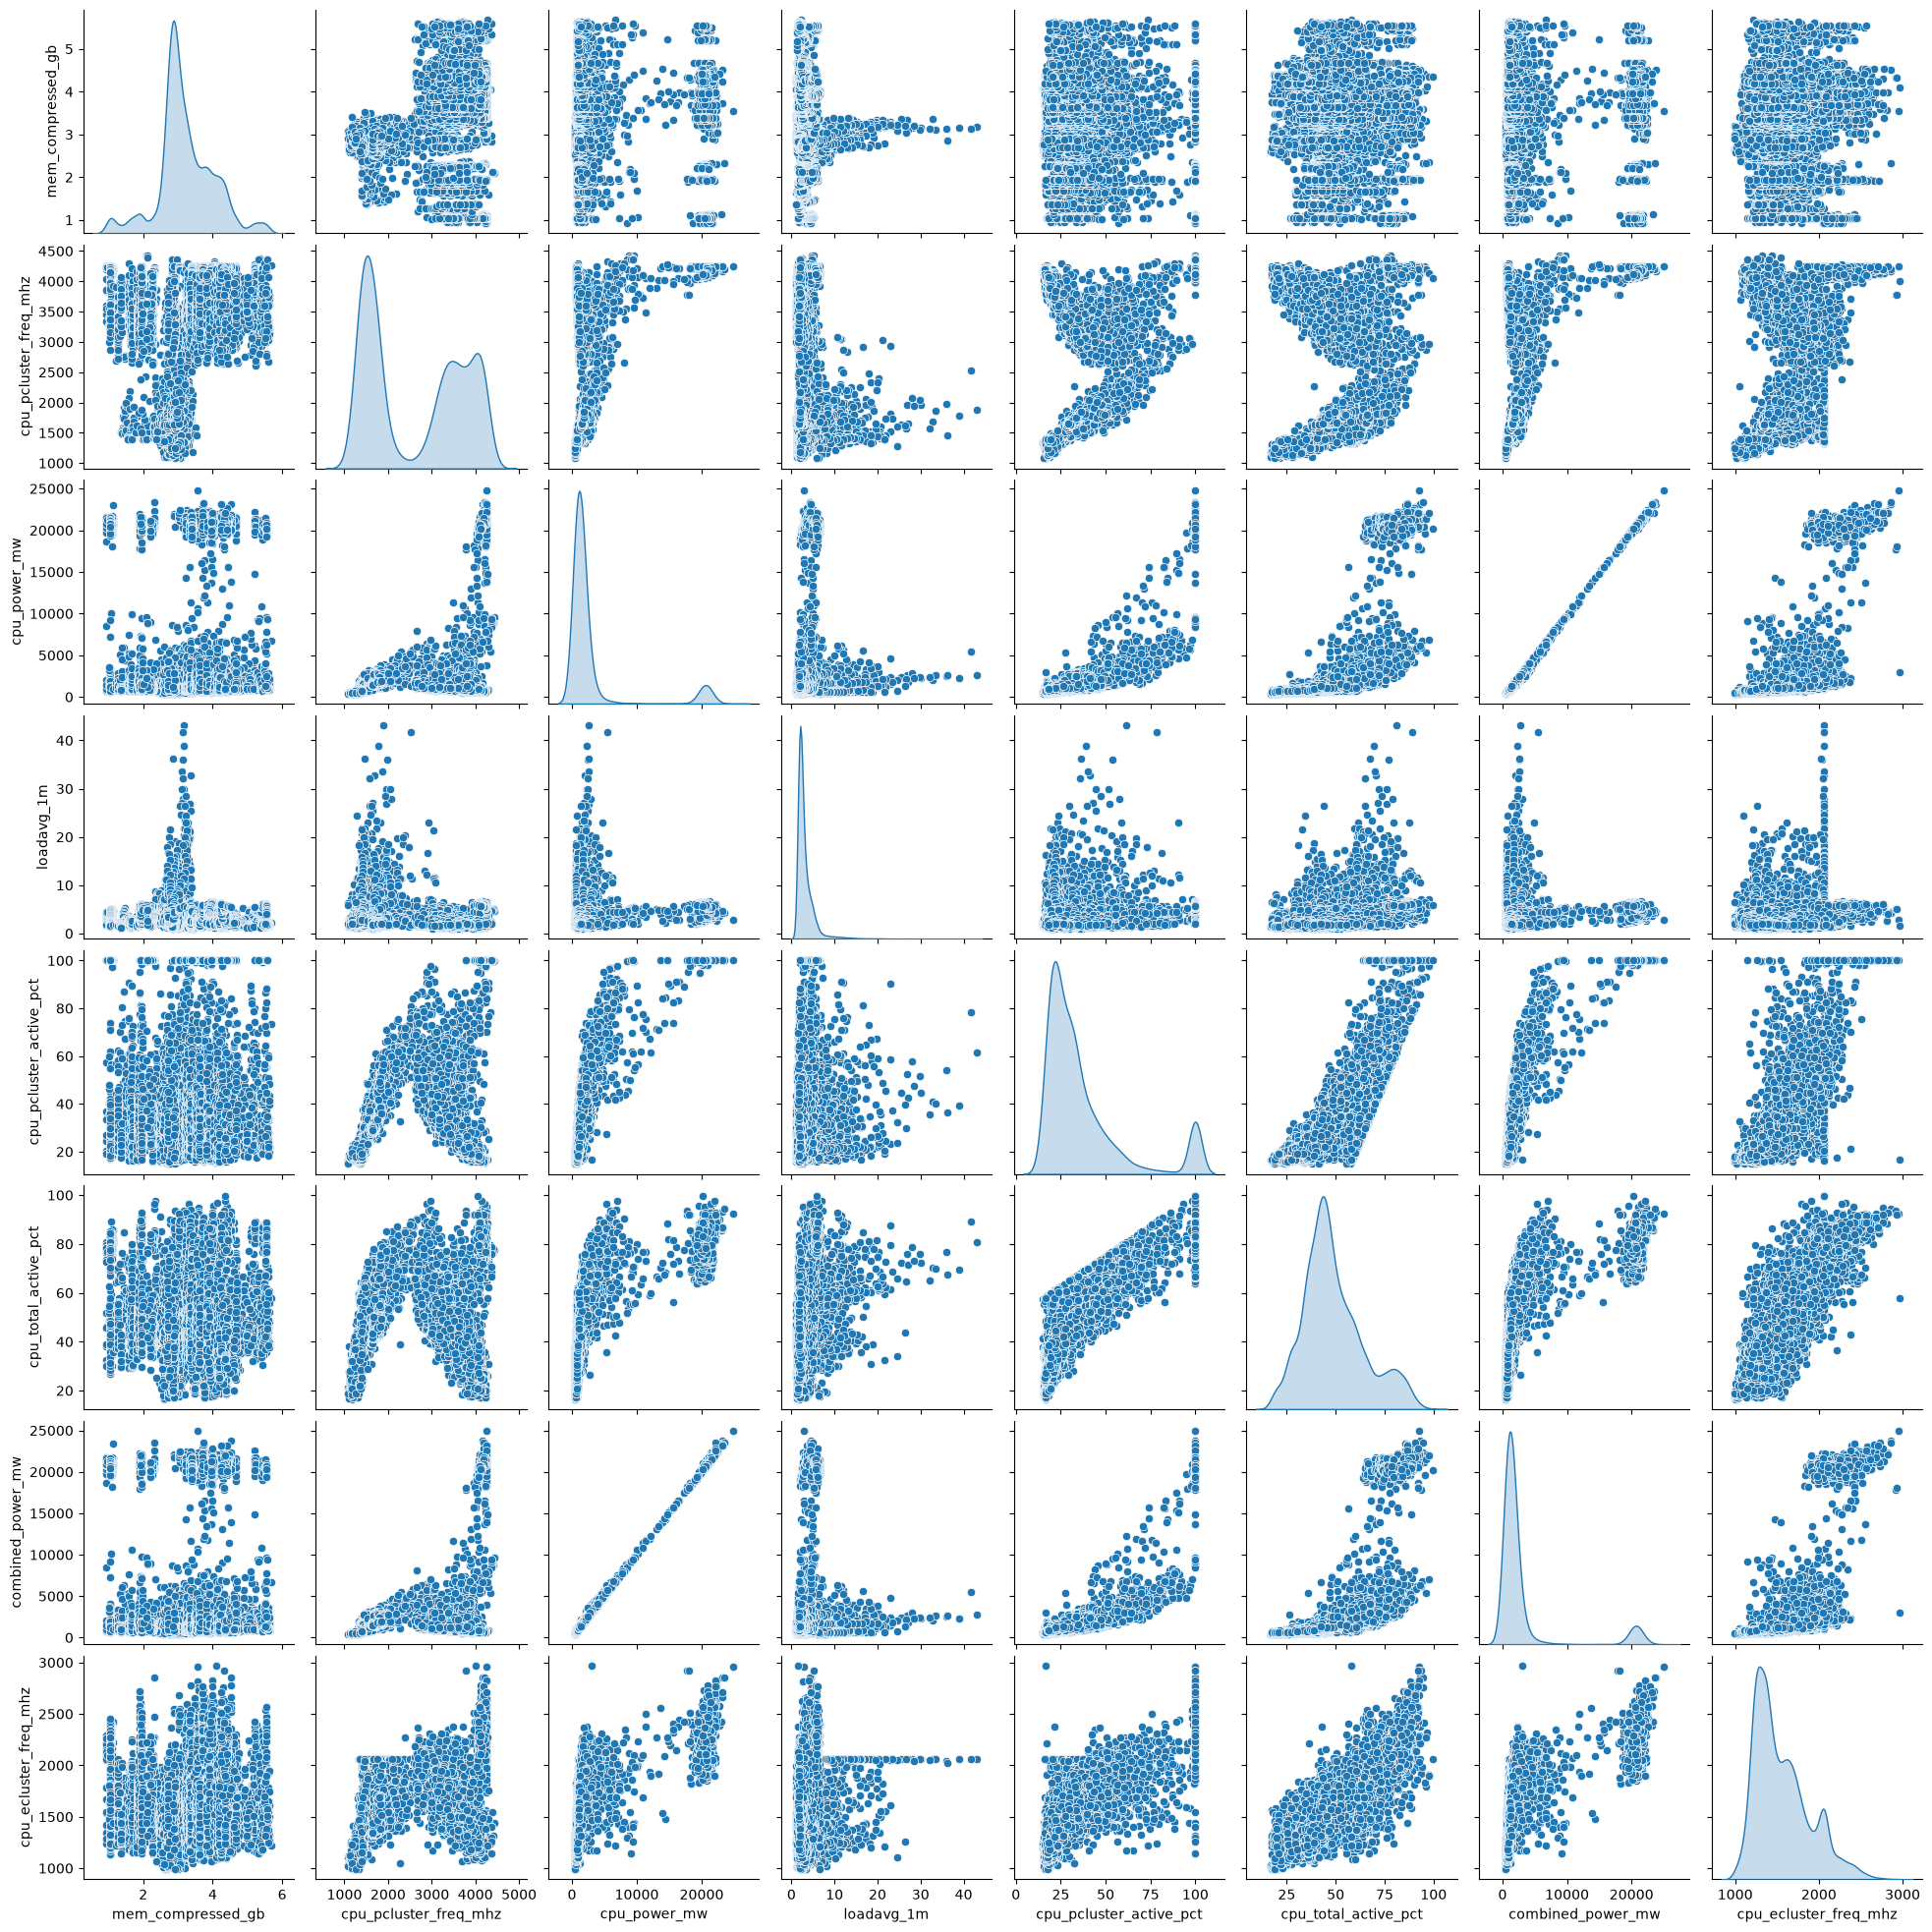

In [17]:
plot_variable_pairplot(df_final)

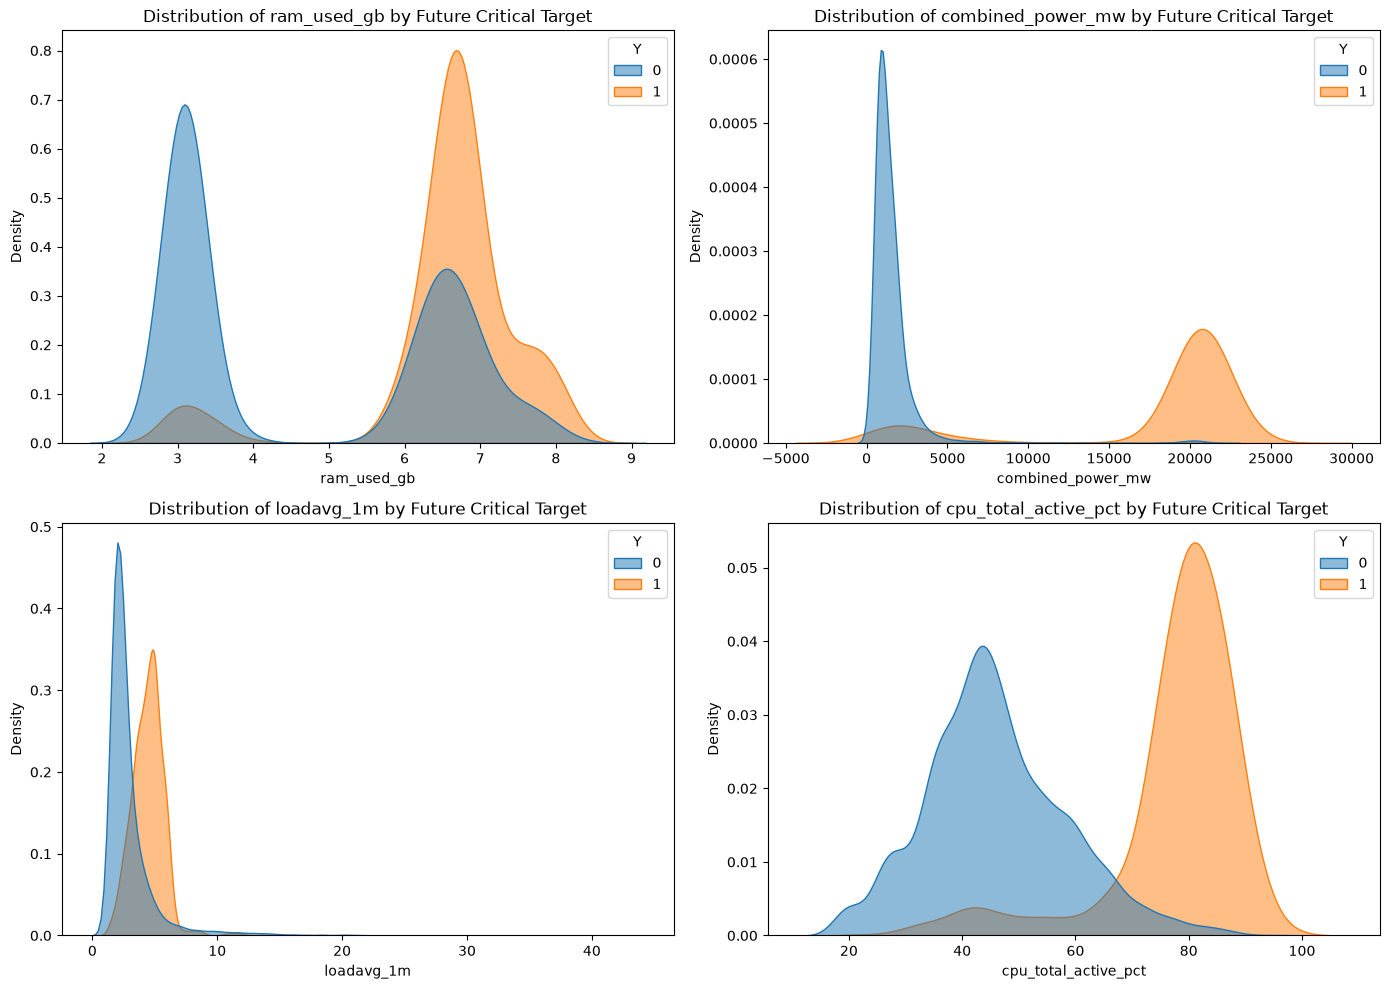

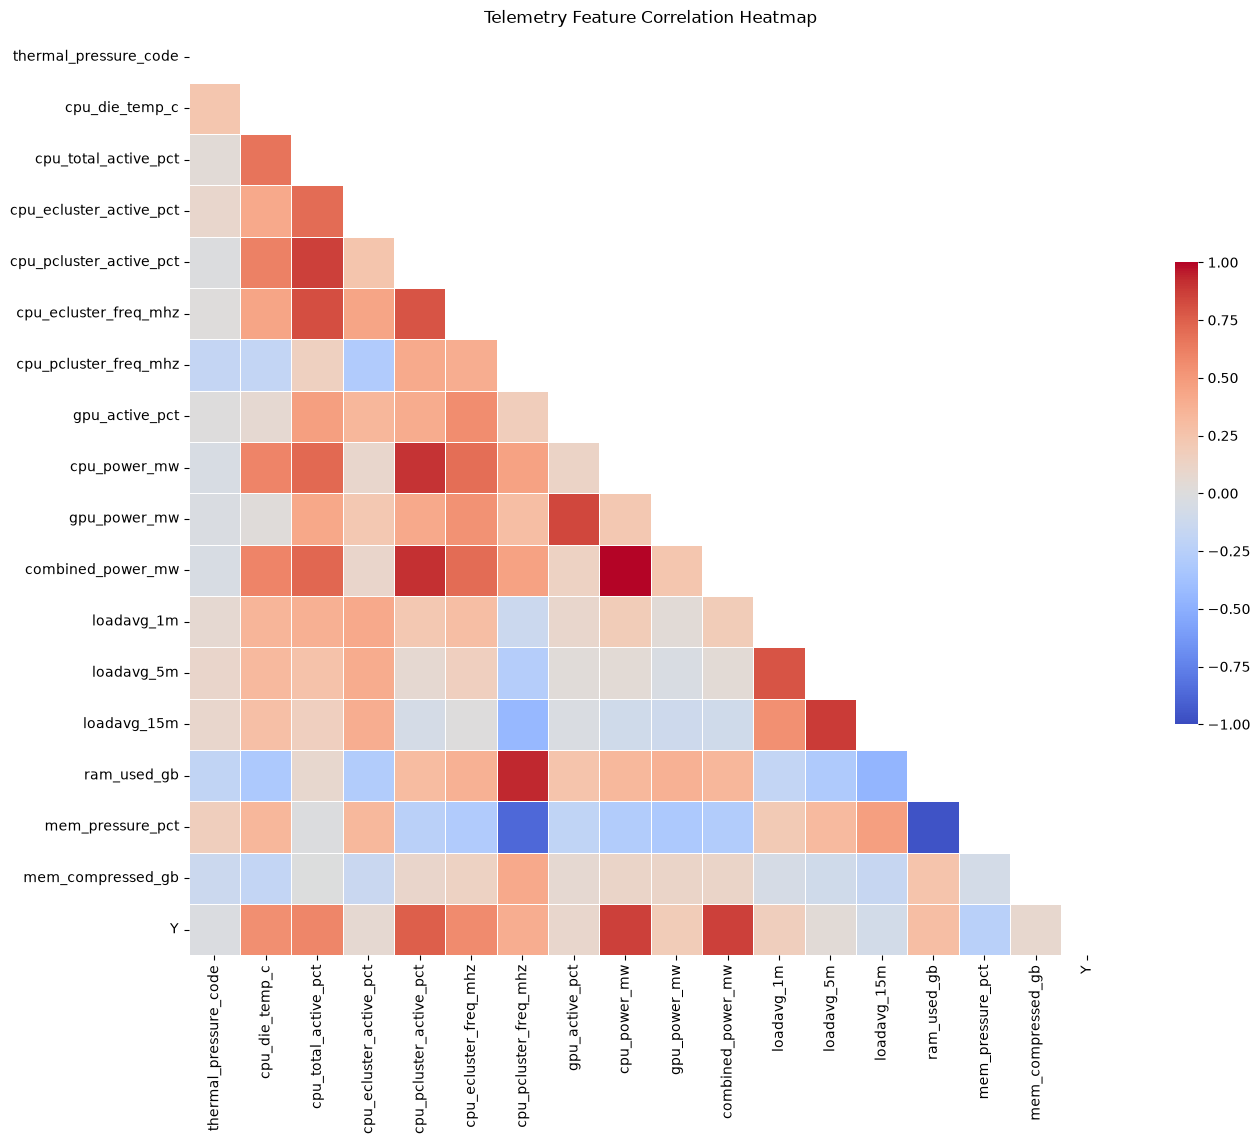


--- Multicollinearity Warnings (r > 0.85) ---
Feature 'cpu_pcluster_active_pct' is highly correlated with ['cpu_total_active_pct']. Consider dropping for linear models.
Feature 'cpu_power_mw' is highly correlated with ['cpu_pcluster_active_pct']. Consider dropping for linear models.
Feature 'combined_power_mw' is highly correlated with ['cpu_pcluster_active_pct', 'cpu_power_mw']. Consider dropping for linear models.
Feature 'loadavg_15m' is highly correlated with ['loadavg_5m']. Consider dropping for linear models.
Feature 'ram_used_gb' is highly correlated with ['cpu_pcluster_freq_mhz']. Consider dropping for linear models.
Feature 'mem_pressure_pct' is highly correlated with ['cpu_pcluster_freq_mhz', 'ram_used_gb']. Consider dropping for linear models.
Feature 'Y' is highly correlated with ['cpu_power_mw', 'combined_power_mw']. Consider dropping for linear models.

--- Top 10 Positively Correlated Features with Target ---
cpu_power_mw               0.859980
combined_power_mw        

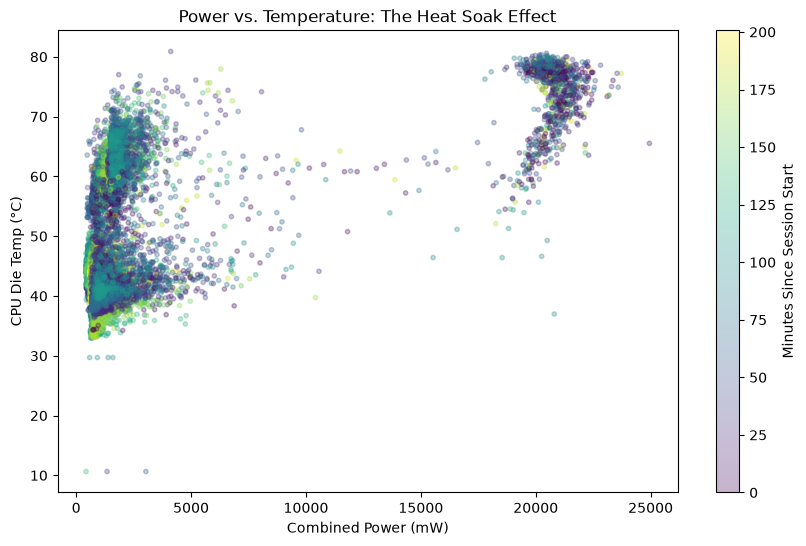

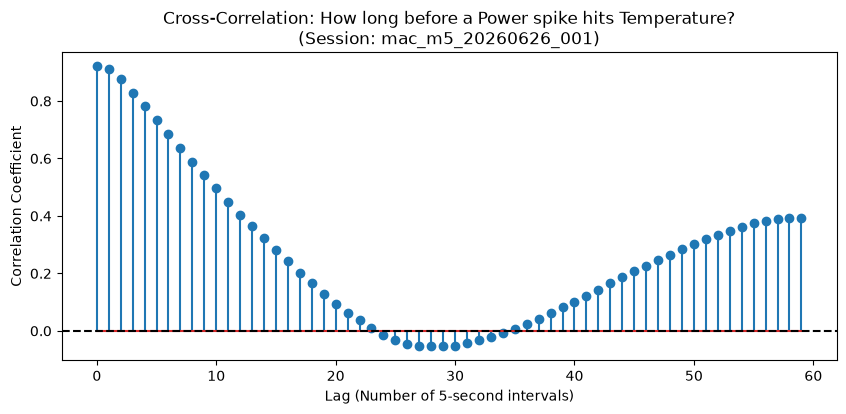


Maximum correlation occurs at a lag of 0 intervals (0 seconds).


In [18]:
plot_univariate_distributions(df_final, target_col="Y")
plot_correlation_heatmap(df_final)
test_heat_soak_assumption(df_final)
plot_power_temp_crosscorr_eda(df_final)

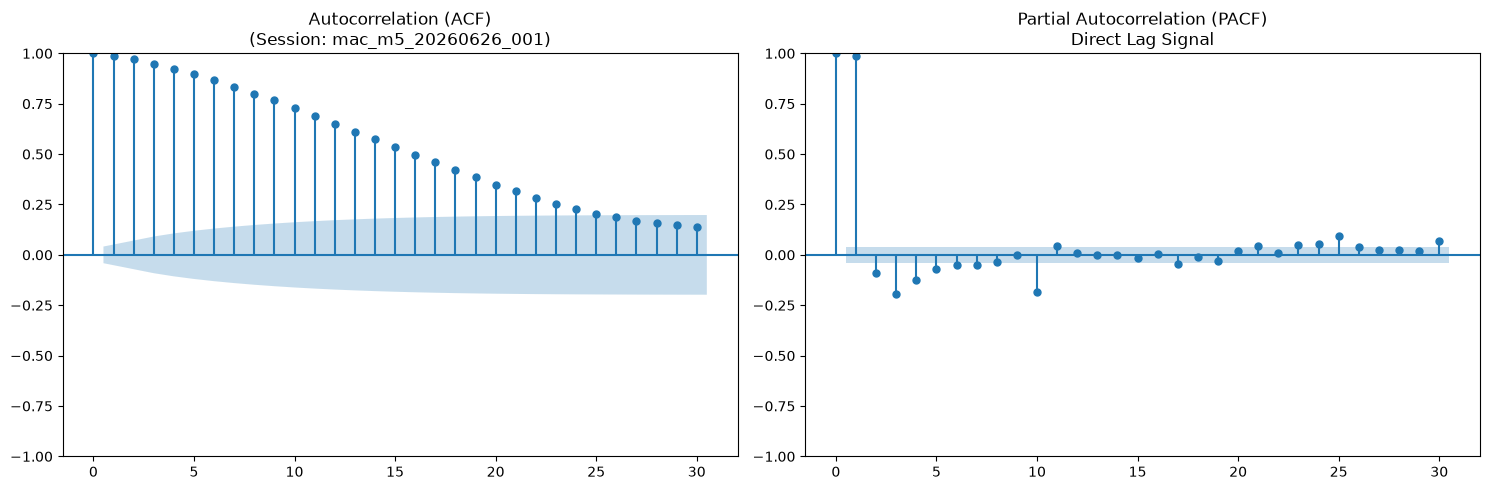


💡 INTERPRETATION:
Look at the PACF plot (right). The point where the stems fall inside the blue shaded area
is where historical data stops providing *new* direct information. Use this to set your max lag features.


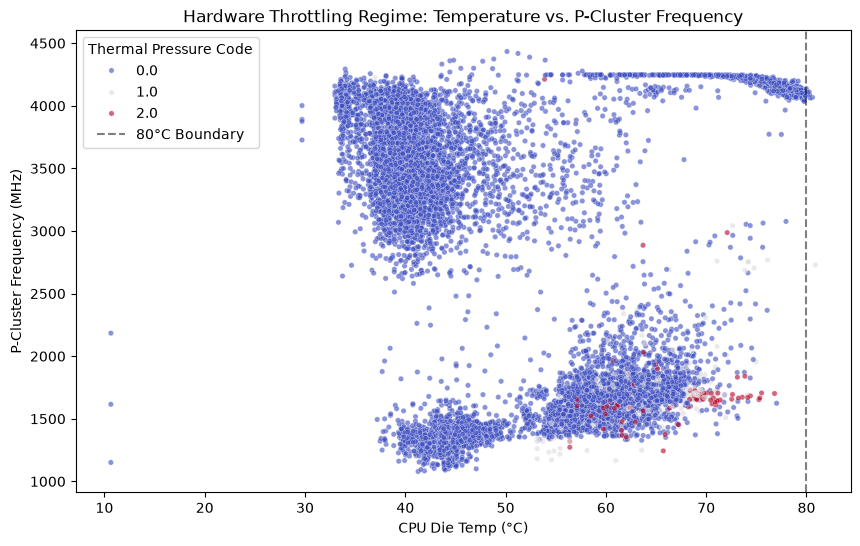

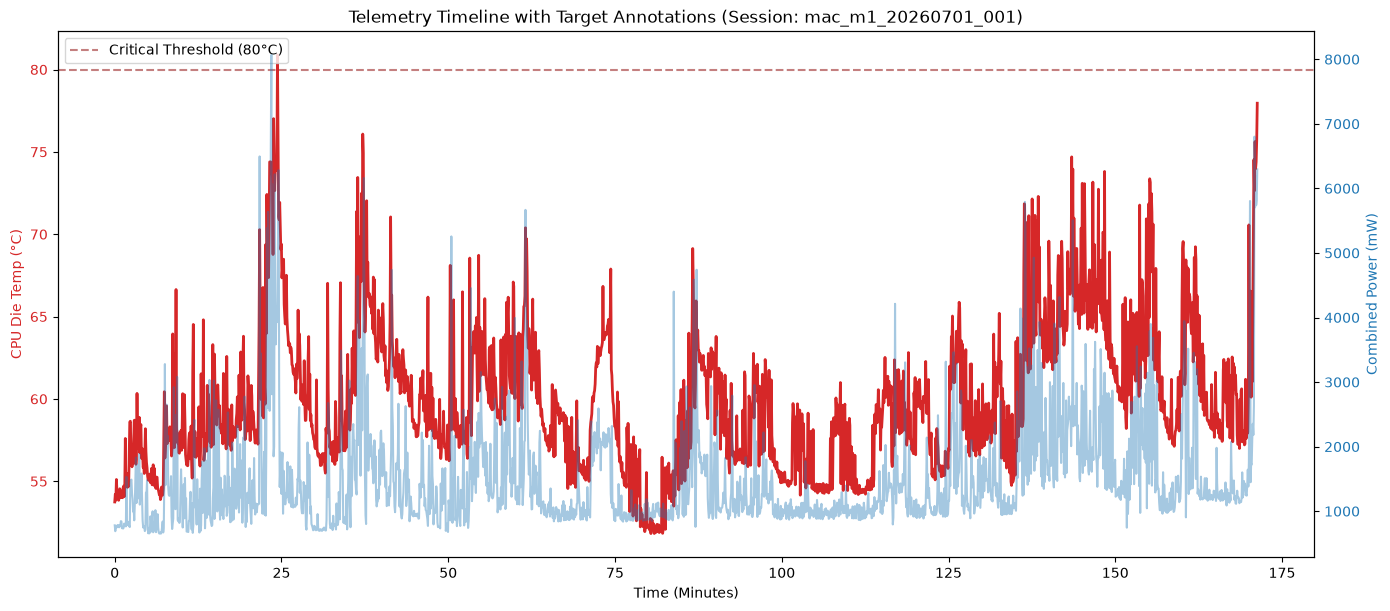


--- Baseline Target Signal (Mutual Information) ---
cpu_power_mw                   0.2184
combined_power_mw              0.2174
cpu_pcluster_active_pct        0.2120
cpu_total_active_pct           0.1848
cpu_pcluster_freq_mhz          0.1706
cpu_ecluster_freq_mhz          0.1608
mem_compressed_gb              0.1451
loadavg_1m                     0.0983
ram_used_gb                    0.0632
mem_pressure_pct               0.0602

💡 Note: Features with high MI scores are your strongest baseline predictors.


In [19]:
plot_autocorrelation(df_final, target_col="cpu_die_temp_c", lags=30)
plot_throttling_regime(df_final)
plot_annotated_timeline(df_final, session_idx=0)
calculate_baseline_target_importance(df_final, target_col="Y")

In [20]:
from data_features import engineer_features, drop_invalid_rows

df_features = engineer_features(df_final)
df_ml_ready = drop_invalid_rows(df_features)

2026-07-05 22:30:30,938 [INFO] Engineering features grouped by session_id.
2026-07-05 22:30:31,002 [INFO] Feature engineering complete.
2026-07-05 22:30:31,006 [INFO] Dropped 232 boundary rows with invalid feature history.


In [21]:
# drop cpu_die_temp_c because it is used to construct the target variable Y
#df_ml_ready = df_ml_ready.drop(columns=["cpu_die_temp_c"])

In [22]:
# compute the correlation highest with the target variable Y
TARGET_COL = "Y"
correlations = df_ml_ready.select_dtypes(include="number").corr()[TARGET_COL].abs().sort_values(ascending=False)

# set display options to all rows
pd.set_option('display.max_rows', None)
# display correlations as pd.Series
display(correlations)

Y                                         1.000000
pcluster_power_pressure                   0.854549
cpu_power_mw                              0.850753
combined_power_mw                         0.850684
cpu_power_mw_lag_1                        0.818918
combined_power_mw_lag_1                   0.818875
combined_power_mw_roll_mean_30s           0.796396
cpu_power_mw_roll_mean_30s                0.796219
cpu_power_mw_lag_2                        0.784799
combined_power_mw_lag_2                   0.784754
combined_power_mw_roll_min_30s            0.769779
cpu_power_mw_roll_min_30s                 0.769033
cpu_power_mw_roll_max_30s                 0.766550
combined_power_mw_roll_max_30s            0.765679
cpu_power_mw_lag_3                        0.748964
combined_power_mw_lag_3                   0.748950
cpu_pcluster_active_pct                   0.737383
cpu_pcluster_active_pct_roll_min_30s      0.736134
cpu_pcluster_active_pct_roll_mean_30s     0.724775
combined_power_mw_roll_mean_1m 

In [23]:
df_ml_ready.shape

(10157, 141)

In [24]:
from data_prep import chronological_session_split_raw, separate_raw

train_df, val_df, test_df = chronological_session_split_raw(df_ml_ready)

X_train, y_train, meta_train = separate_raw(train_df)
X_val, y_val, meta_val = separate_raw(val_df)
X_test, y_test, meta_test = separate_raw(test_df)

rf, gb, rf_imp, gb_imp = fit_tree_importance(X_train, y_train, X_train.columns)

print("RF top 20")
display(rf_imp.head(20))

print("GB top 20")
display(gb_imp.head(20))

perm_imp, perm_std = get_permutation_importance(rf, X_val, y_val, X_val.columns, scoring="f1")
print("Permutation top 20 - Random Forest")
display(perm_imp.head(20))

print("Permutation top 20 - Gradient Boosting")
perm_imp_gb, perm_std_gb = get_permutation_importance(gb, X_val, y_val, X_val.columns, scoring="f1")
display(perm_imp_gb.head(20))

RF top 20


combined_power_mw                        0.090004
cpu_die_temp_c                           0.080221
cpu_power_mw                             0.058392
combined_power_mw_lag_1                  0.045873
cpu_total_active_pct                     0.043477
cpu_pcluster_active_pct_lag_1            0.043141
pcluster_power_pressure                  0.040456
cpu_pcluster_active_pct                  0.039946
cpu_die_temp_c_lag_1                     0.032863
cpu_power_mw_roll_max_30s                0.029779
cpu_power_mw_lag_1                       0.029664
cpu_die_temp_c_roll_max_30s              0.026985
cpu_die_temp_c_diff_6                    0.023655
cpu_die_temp_c_diff_1                    0.023127
combined_power_mw_roll_max_30s           0.021971
combined_power_mw_lag_2                  0.019758
cpu_power_mw_roll_mean_30s               0.016486
combined_power_mw_roll_mean_30s          0.016404
cpu_pcluster_active_pct_roll_max_30s     0.014564
cpu_pcluster_active_pct_roll_mean_30s    0.013052


GB top 20


cpu_power_mw                            0.604806
cpu_die_temp_c                          0.132983
cpu_die_temp_c_diff_6                   0.109462
combined_power_mw                       0.042048
pcluster_power_pressure                 0.019153
cpu_die_temp_c_roll_mean_5m             0.010848
cpu_die_temp_c_diff_1                   0.010133
cpu_pcluster_active_pct_roll_mean_5m    0.009317
cpu_pcluster_freq_mhz_roll_range_5m     0.008812
thermal_distress_proxy                  0.005123
cpu_pcluster_freq_mhz_roll_min_5m       0.004534
cpu_pcluster_freq_mhz_roll_max_1m       0.004164
cpu_die_temp_c_roll_min_5m              0.003649
cpu_die_temp_c_roll_mean_15m            0.002954
cpu_pcluster_freq_mhz_roll_mean_15m     0.002723
cpu_die_temp_c_lag_10                   0.001861
cpu_power_mw_roll_range_5m              0.001809
loadavg_1m                              0.001777
cpu_power_mw_roll_max_5m                0.001682
cpu_die_temp_c_roll_min_30s             0.001564
dtype: float64

Permutation top 20 - Random Forest


cpu_die_temp_c_diff_1                   0.124882
cpu_die_temp_c_diff_6                   0.085027
cpu_die_temp_c_roll_range_1m            0.024355
cpu_die_temp_c_roll_std_30s             0.016056
combined_power_mw_roll_mean_5m          0.012403
cpu_die_temp_c                          0.011542
cpu_die_temp_c_roll_range_30s           0.011349
cpu_ecluster_freq_mhz                   0.009556
cpu_die_temp_c_roll_range_5m            0.007751
cpu_total_active_pct                    0.005525
cpu_pcluster_active_pct_roll_mean_5m    0.003249
combined_power_mw_roll_mean_30s         0.002270
gpu_active_pct                          0.002270
cpu_pcluster_active_pct_roll_min_1m     0.002144
combined_power_mw_lag_2                 0.001766
combined_power_mw_roll_std_30s          0.001514
combined_power_mw_roll_min_5m           0.001514
cpu_power_mw_roll_max_1m                0.001387
cpu_power_mw_lag_3                      0.001135
cpu_pcluster_freq_mhz_roll_std_30s      0.000757
dtype: float64

Permutation top 20 - Gradient Boosting


cpu_die_temp_c                          0.048733
cpu_die_temp_c_diff_1                   0.009432
cpu_die_temp_c_diff_6                   0.009226
cpu_pcluster_freq_mhz_roll_range_5m     0.008360
cpu_pcluster_active_pct_roll_min_1m     0.003690
cpu_pcluster_active_pct_lag_1           0.003617
cpu_die_temp_c_roll_mean_5m             0.002982
mem_pressure_pct                        0.002296
cpu_die_temp_c_roll_mean_15m            0.001056
cpu_pcluster_active_pct_roll_std_5m     0.000674
cpu_pcluster_active_pct_roll_std_1m     0.000061
cpu_power_mw_roll_std_1m                0.000044
cpu_pcluster_active_pct_roll_mean_5m    0.000035
cpu_pcluster_active_pct                 0.000000
cpu_ecluster_active_pct                 0.000000
cpu_power_mw_diff_1                     0.000000
gpu_active_pct                          0.000000
cpu_ecluster_freq_mhz                   0.000000
cpu_pcluster_freq_mhz                   0.000000
loadavg_1m                              0.000000
dtype: float64

In [25]:
from data_features import aggregate_family_importance
print("\n--- RF permutation importance by feature family ---")
display(aggregate_family_importance(perm_imp))

# Step 5 — identify features safe to drop
# Negative permutation importance means the feature HURTS the model
safe_to_drop = perm_imp[perm_imp <= 0].index.tolist()
low_contribution = perm_imp[(perm_imp > 0) & (perm_imp < 0.002)].index.tolist()

print(f"\nSafe to drop (perm imp <= 0): {len(safe_to_drop)}")
print(safe_to_drop)
print(f"\nLow contribution (perm imp < 0.002): {len(low_contribution)}")


--- RF permutation importance by feature family ---


family
diff           0.159610
interaction    0.000000
raw_core      -0.007718
accel         -0.008587
other         -0.017077
lag           -0.090315
rolling       -0.286363
Name: importance, dtype: float64


Safe to drop (perm imp <= 0): 107
['pcluster_power_pressure', 'cpu_pcluster_freq_mhz', 'cpu_power_mw_accel', 'combined_power_mw_lag_4', 'combined_power_mw_lag_5', 'combined_power_mw_lag_10', 'cpu_pcluster_active_pct_lag_1', 'mem_pressure_pct', 'cpu_power_mw_lag_1', 'ram_used_gb', 'gpu_power_mw', 'combined_power_mw_roll_max_1m', 'cpu_die_temp_c_roll_min_5m', 'combined_power_mw_roll_range_30s', 'combined_power_mw_roll_max_30s', 'cpu_die_temp_c_roll_max_5m', 'cpu_pcluster_freq_mhz_lag_1', 'cpu_pcluster_freq_mhz_lag_3', 'cpu_pcluster_freq_mhz_lag_2', 'cpu_pcluster_freq_mhz_lag_5', 'cpu_pcluster_freq_mhz_roll_mean_5m', 'cpu_pcluster_freq_mhz_roll_min_1m', 'cpu_pcluster_freq_mhz_roll_max_1m', 'cpu_pcluster_freq_mhz_roll_min_30s', 'cpu_power_mw_roll_max_5m', 'cpu_pcluster_active_pct_roll_range_30s', 'cpu_pcluster_active_pct_roll_std_30s', 'combined_power_mw_roll_std_5m', 'cpu_power_mw_roll_max_30s', 'cpu_power_mw_roll_mean_1m', 'cpu_power_mw_roll_mean_5m', 'cpu_die_temp_c_roll_min_30s', 'cpu

In [26]:
KEEP_COLS = [
    "pcluster_power_pressure",
    "cpu_power_mw",
    "combined_power_mw",
    "combined_power_mw_is_high",
    "cpu_pcluster_active_pct",
    "cpu_die_temp_c_lag_1",
    "cpu_total_active_pct",
    "combined_power_mw_roll_max_30s",
    "cpu_die_temp_c_roll_max_30s",
    "cpu_power_mw_is_high",
    "combined_power_mw_lag_1",
    "cpu_pcluster_active_pct_lag_1",
    "cpu_die_temp_c_diff_6",
    "cpu_power_mw_lag_1",
    "cpu_die_temp_c_diff_1",
    "combined_power_mw_roll_mean_30s",
    "thermal_distress_proxy",
    "cpu_power_mw_roll_max_30s",
    "cpu_pcluster_active_pct_roll_max_30s",
    "cpu_ecluster_freq_mhz",
    "cpu_die_temp_c_roll_mean_30s",
    "loadavg_5m",
    "cpu_pcluster_freq_mhz",
    "ram_used_gb",
]

keep_all = ["session_id", "timestamp_utc", "Y"] + KEEP_COLS
df_final_model = df_ml_ready[[c for c in keep_all if c in df_ml_ready.columns]].copy()
splits = build_ml_splits(df_final_model)

X_train, y_train, meta_train = splits["train"]
X_val, y_val, meta_val = splits["val"]
X_test, y_test, meta_test = splits["test"]
bundle = splits["bundle"]

2026-07-05 22:31:06,384 [INFO] Chronological session split — train 70% / val 15% / test 15%.
2026-07-05 22:31:06,391 [INFO] Sessions assigned — train: 5, val: 1, test: 2.
2026-07-05 22:31:06,398 [INFO] Column routing — passthrough: 0, multimodal_base: 7, multimodal_children: 10, diff/accel (YJ): 2, box-cox: 3, yj-fallback: 0
2026-07-05 22:31:06,439 [INFO] Box-Cox fitted on 3 columns.
2026-07-05 22:31:06,453 [INFO] Yeo-Johnson fitted on 2 columns (2 diff/accel + 0 other fallback).
2026-07-05 22:31:06,455 [INFO] Preprocessing bundle saved to artifacts/preprocessors.joblib.
2026-07-05 22:31:06,456 [INFO] Transforming X_train...
2026-07-05 22:31:06,462 [INFO] Transforming X_val...
2026-07-05 22:31:06,467 [INFO] Transforming X_test...


In [27]:
X_train.shape

(5009, 29)

In [28]:
X_train.head()

,pcluster_power_pressure,cpu_power_mw,combined_power_mw,cpu_pcluster_active_pct,cpu_die_temp_c_lag_1,cpu_total_active_pct,combined_power_mw_roll_max_30s,cpu_die_temp_c_roll_max_30s,combined_power_mw_lag_1,cpu_pcluster_active_pct_lag_1,...,loadavg_5m,cpu_pcluster_freq_mhz,ram_used_gb,cpu_power_mw_is_high,combined_power_mw_is_high,cpu_pcluster_active_pct_is_high,cpu_total_active_pct_is_high,loadavg_5m_is_high,cpu_pcluster_freq_mhz_is_high,ram_used_gb_is_high
5148,1.660461,12.348152,11.062885,2.406382,3.942191,1.368918,5.105660,2.891104,11.468143,2.404429,...,0.220332,0.846024,0.344593,1,1,1,1,1,0,0
5149,1.673458,13.355708,12.160276,2.406382,3.934887,2.025001,5.423444,2.914777,11.048661,2.404429,...,0.239047,0.844543,0.324279,1,1,1,1,1,0,0
5150,1.665208,12.704023,11.543087,2.406382,3.973197,1.874098,5.423444,3.060814,12.144674,2.404429,...,0.286687,0.804728,0.285340,1,1,1,1,1,0,0
5151,1.663091,12.543664,11.352337,2.406382,4.164474,1.724184,5.423444,3.097638,11.528261,2.404429,...,0.304551,0.810405,0.039872,1,1,1,1,1,0,0
5152,1.658036,12.171397,11.045112,2.406382,4.212707,1.790076,5.423444,3.106319,11.337749,2.404429,...,0.336453,0.796669,0.181784,1,1,1,1,1,0,0


In the following cells we are going to train different models with different class balancing techniques (no balancing, class weights, random oversampling, SMOTE and threshold moving after probability prediction)

In [35]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

rand_state=42


### Logistic regression

In [36]:
# --- A. Baseline ---
lr_baseline = LogisticRegression(max_iter=1000, random_state=rand_state)
lr_baseline.fit(X_train, y_train)

# --- B. Class Weights ---
lr_weighted = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=rand_state)
lr_weighted.fit(X_train, y_train)


# --- C. Random oversampling ---
ros = RandomOverSampler(random_state=rand_state)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
lr_rand_oversamp = LogisticRegression(max_iter=1000, random_state=rand_state)
lr_rand_oversamp.fit(X_train_ros, y_train_ros)


# --- D. SMOTE ---
smote = SMOTE(random_state=rand_state)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
lr_smote = LogisticRegression(max_iter=1000, random_state=rand_state)
lr_smote.fit(X_train_sm, y_train_sm)

# --- E. Threshold Moving ---
val_probs = lr_baseline.predict_proba(X_val)[:, 1]
best_thresh = 0.5
best_f1 = 0
for t in np.linspace(0, 1, 100):
    preds = (val_probs >= t).astype(int)
    score = f1_score(y_val, preds)
    if score > best_f1:
        best_f1, best_thresh = score, t




### Random forest

In [37]:
from sklearn.ensemble import RandomForestClassifier
# --- A. Baseline ---
rf_baseline = RandomForestClassifier(random_state=rand_state)
rf_baseline.fit(X_train, y_train)

# --- B. Class Weights ---
rf_weighted = RandomForestClassifier(class_weight="balanced", random_state=rand_state)
rf_weighted.fit(X_train, y_train)

# --- C. Random oversampling ---
ros = RandomOverSampler(random_state=rand_state)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
rf_rand_oversamp = RandomForestClassifier(random_state=rand_state)
rf_rand_oversamp.fit(X_train_ros, y_train_ros)

# --- D. SMOTE ---
smote = SMOTE(random_state=rand_state)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
rf_smote = RandomForestClassifier(random_state=rand_state)
rf_smote.fit(X_train_sm, y_train_sm)

# --- E. Threshold Moving (Optimized on RF Baseline) ---
rf_val_probs = rf_baseline.predict_proba(X_val)[:, 1]
rf_best_thresh = 0.5
rf_best_f1 = 0
for t in np.linspace(0, 1, 100):
    preds = (rf_val_probs >= t).astype(int)
    score = f1_score(y_val, preds)
    if score > rf_best_f1:
        rf_best_f1, rf_best_thresh = score, t

### Gradient boosting

In [38]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# --- A. Baseline ---
gb_baseline = GradientBoostingClassifier(random_state=rand_state)
gb_baseline.fit(X_train, y_train)

# --- B. Class Weights (via Sample Weights) ---
gb_sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
gb_weighted = GradientBoostingClassifier(random_state=rand_state)
gb_weighted.fit(X_train, y_train, sample_weight=gb_sample_weights)

# --- C. Random Oversampling ---
X_train_ros, y_train_ros = RandomOverSampler(random_state=rand_state).fit_resample(X_train, y_train)
gb_rand_oversamp = GradientBoostingClassifier(random_state=rand_state)
gb_rand_oversamp.fit(X_train_ros, y_train_ros)

# --- D. SMOTE ---
X_train_sm, y_train_sm = SMOTE(random_state=rand_state).fit_resample(X_train, y_train)
gb_smote = GradientBoostingClassifier(random_state=rand_state)
gb_smote.fit(X_train_sm, y_train_sm)

# --- E. Threshold Moving ---
gb_val_probs = gb_baseline.predict_proba(X_val)[:, 1]
gb_best_thresh = 0.5
gb_best_f1 = 0
for t in np.linspace(0, 1, 100):
    preds = (gb_val_probs >= t).astype(int)
    score = f1_score(y_val, preds)
    if score > gb_best_f1:
        gb_best_f1, gb_best_thresh = score, t

### Newral network

In [39]:
from sklearn.neural_network import MLPClassifier

# --- A. Baseline ---
mlp_baseline = MLPClassifier(max_iter=500, random_state=rand_state)
mlp_baseline.fit(X_train, y_train)

# --- B. Class Weights (via Sample Weights) ---
mlp_sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
mlp_weighted = MLPClassifier(max_iter=500, random_state=rand_state)
mlp_weighted.fit(X_train, y_train, sample_weight=mlp_sample_weights)

# --- C. Random Oversampling ---
X_train_ros, y_train_ros = RandomOverSampler(random_state=rand_state).fit_resample(X_train, y_train)
mlp_rand_oversamp = MLPClassifier(max_iter=500, random_state=rand_state)
mlp_rand_oversamp.fit(X_train_ros, y_train_ros)

# --- D. SMOTE ---
X_train_sm, y_train_sm = SMOTE(random_state=rand_state).fit_resample(X_train, y_train)
mlp_smote = MLPClassifier(max_iter=500, random_state=rand_state)
mlp_smote.fit(X_train_sm, y_train_sm)

# --- E. Threshold Moving ---
mlp_val_probs = mlp_baseline.predict_proba(X_val)[:, 1]
mlp_best_thresh = 0.5
mlp_best_f1 = 0
for t in np.linspace(0, 1, 100):
    preds = (mlp_val_probs >= t).astype(int)
    score = f1_score(y_val, preds)
    if score > mlp_best_f1:
        mlp_best_f1, mlp_best_thresh = score, t

##### Class balancing technique performance overview

In [ ]:

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

#Structure to hold all trained models and their variations
all_models = {
    "Logistic Regression": {
        "Baseline": lr_baseline,
        "Class Weights": lr_weighted,
        "Random Oversampling": lr_rand_oversamp,
        "SMOTE": lr_smote,
        "type": "standard"
    },
    "Random Forest": {
        "Baseline": rf_baseline,
        "Class Weights": rf_weighted,
        "Random Oversampling": rf_rand_oversamp,
        "SMOTE": rf_smote,
        "type": "standard"
    },
    "Gradient Boosting": {
        "Baseline": gb_baseline,
        "Class Weights": gb_weighted,
        "Random Oversampling": gb_rand_oversamp,
        "SMOTE": gb_smote,
        "type": "standard"
    },
    "Neural Network": {
        "Baseline": mlp_baseline,
        "Class Weights": mlp_weighted,
        "Random Oversampling": mlp_rand_oversamp,
        "SMOTE": mlp_smote,
        "type": "standard"
    }
}

#Dictionary to collect all results for the final master table
final_results = {}

#Iterate through each model type
for model_name, techniques in all_models.items():
    
    # ----------------------------------------------------------------
    # Evaluate Standard Techniques (Baseline, Class Weights, ROS, SMOTE)
    # ----------------------------------------------------------------
    standard_strats = ["Baseline", "Class Weights", "Random Oversampling", "SMOTE"]
    
    for strat in standard_strats:
        model = techniques[strat]
        
        # Validation evaluation
        val_preds = model.predict(X_val)
        val_prec = precision_score(y_val, val_preds, zero_division=0)
        val_rec = recall_score(y_val, val_preds, zero_division=0)
        val_f1 = f1_score(y_val, val_preds, zero_division=0)
        
        # Test evaluation
        test_preds = model.predict(X_test)
        test_prec = precision_score(y_test, test_preds, zero_division=0)
        test_rec = recall_score(y_test, test_preds, zero_division=0)
        test_f1 = f1_score(y_test, test_preds, zero_division=0)
        
        # Store metrics
        final_results[f"{model_name} - {strat}"] = {
            "Val Prec": val_prec, "Val Rec": val_rec, "Val F1": val_f1,
            "Test Prec": test_prec, "Test Rec": test_rec, "Test F1": test_f1
        }
        
    # ----------------------------------------------------------------
    # Evaluate Threshold Moving (on the Baseline Model)
    # ----------------------------------------------------------------
    baseline_model = techniques["Baseline"]
    
    # Get raw probabilities
    val_probs = baseline_model.predict_proba(X_val)[:, 1]
    test_probs = baseline_model.predict_proba(X_test)[:, 1]
    
    # Find best threshold on Validation Set
    best_thresh = 0.5
    best_val_f1 = 0
    
    for t in np.linspace(0, 1, 100):
        preds = (val_probs >= t).astype(int)
        score = f1_score(y_val, preds, zero_division=0)
        if score > best_val_f1:
            best_val_f1 = score
            best_thresh = t
            
    # Calculate final validation metrics at the optimized threshold
    val_preds_t = (val_probs >= best_thresh).astype(int)
    val_prec_t = precision_score(y_val, val_preds_t, zero_division=0)
    val_rec_t = recall_score(y_val, val_preds_t, zero_division=0)
    
    # Apply that exact validation-optimized threshold to the Test Set
    test_preds_t = (test_probs >= best_thresh).astype(int)
    test_prec_t = precision_score(y_test, test_preds_t, zero_division=0)
    test_rec_t = recall_score(y_test, test_preds_t, zero_division=0)
    test_f1_t = f1_score(y_test, test_preds_t, zero_division=0)
    
    # Store metrics
    final_results[f"{model_name} - Thresh Moving (t={best_thresh:.2f})"] = {
        "Val Prec": val_prec_t, "Val Rec": val_rec_t, "Val F1": best_val_f1,
        "Test Prec": test_prec_t, "Test Rec": test_rec_t, "Test F1": test_f1_t
    }

# ----------------------------------------------------------------
# Display Global Side-by-Side Comparison Matrix
# ----------------------------------------------------------------
df_comparison = pd.DataFrame(final_results).T

print("\n=========================================================================")
print("===              ALL TECHNIQUES: VALIDATION VS TEST METRICS            ===")
print("=========================================================================")
print(df_comparison.round(4).to_string())


===              ALL TECHNIQUES: VALIDATION VS TEST METRICS            ===
                                              Val Prec  Val Rec  Val F1  Test Prec  Test Rec  Test F1
Logistic Regression - Baseline                  0.0241   0.9020  0.0470     0.0107    1.0000   0.0212
Logistic Regression - Class Weights             0.0241   0.9412  0.0470     0.0057    1.0000   0.0112
Logistic Regression - Random Oversampling       0.0245   0.9608  0.0477     0.0056    1.0000   0.0111
Logistic Regression - SMOTE                     0.0256   0.8824  0.0497     0.0109    1.0000   0.0215
Logistic Regression - Thresh Moving (t=0.99)    0.1021   0.4706  0.1678     0.0406    1.0000   0.0780
Random Forest - Baseline                        0.1731   0.1765  0.1748     0.0116    0.0625   0.0196
Random Forest - Class Weights                   0.1628   0.1373  0.1489     0.0189    0.0625   0.0290
Random Forest - Random Oversampling             0.2051   0.1569  0.1778     0.0189    0.0625   0.0290
Random